# Active Flow Control over an Airfoil Using Deep Reinforcement Learning

This work implements AFC over the NACA 0012 airfoil, directly following the methodology of Li et al. (2025). The CFD solver is DOLFINx (IPCS, Taylor-Hood P2/P1). We extend the original paper by supporting arbitrary NACA profiles, configurable jet locations, and adjustable probe density.

**Primary reference:**
```bibtex
@article{10.1063/5.0245111,
    author = {Li, Kaiyu (励凯宇) and Liang, Zhiquan (梁志铨) and Fan, Hao (樊昊) and Liang, Wenkai (梁文恺)},
    title = {Time-resolved deep reinforcement learning for control of the flow past an airfoil},
    journal = {Physics of Fluids},
    volume = {37},
    number = {1},
    pages = {017118},
    year = {2025},
    month = {01},
    abstract = {},
    issn = {1070-6631},
    doi = {10.1063/5.0245111},
    url = {https://doi.org/10.1063/5.0245111},
    eprint = {https://pubs.aip.org/aip/pof/article-pdf/doi/10.1063/5.0245111/20336120/017118_1_5.0245111.pdf},
}
```

**CFD framework:** We also thank Dokken, J. S. (2026). *FEniCSx Tutorial — Flow past a cylinder.* https://jsdokken.com/dolfinx-tutorial tutorial which was integral in getting the CFD running. 

### Necessary Imports/ Airfoil File Path

Note: 
- Format: Place the .dat file within the `/airfoils` folder.
- Geometry: Ensure the profile is fully closed and defined sequentially from **Leading Edge (LE)** to **Trailing Edge (TE)**. 
- Define the file path to your specific airfoil of choice. 

In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

file_path = 'airfoils/naca001234.dat'

from src.configuration.AirfoilConfig import AirfoilConfig
from src.cfd.CFDParameters import CFDParameters

/Users/biplovebaral/Desktop/AFC_DRL/src/cfd/CFDParameters.py:3: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  import tqdm.autonotebook


### Airfoil Configuration

Initializing an `AirfoilConfig` object automatically generates a mesh tailored to the specified **Angle of Attack (AoA)**.

Arguments for the class include: 
- `alpha`: Angle of Attack measured in degrees.
- `NACA_file`: Local path to the airfoil geometry `.dat` file.
- `jet_locs`: A list of three chord-wise $x$-positions for the upper-surface jets (normalized between `0` and `1`).
- `probe_density`: Defines the sensor grid resolution:
    * `"fine"`: $16 \times 12$ array (**192 probes**)
    * `"coarse"`: $8 \times 6$ array (**48 probes**)

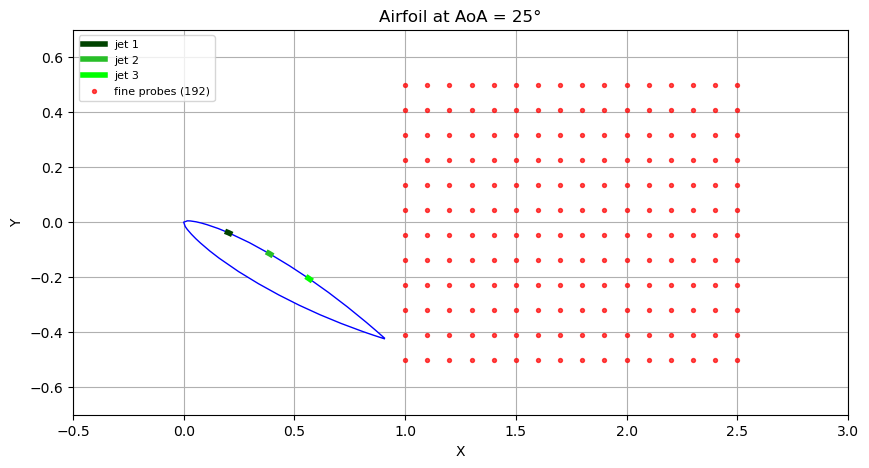

Info    : Running '/Users/biplovebaral/.local/share/mamba/envs/dolfinx_env/bin/gmsh -2 /Users/biplovebaral/Desktop/AFC_DRL/src/configuration/geo_and_mesh/naca001234_25.geo -o /Users/biplovebaral/Desktop/AFC_DRL/src/configuration/geo_and_mesh/naca001234_25.msh' [Gmsh 4.15.1, 1 node, max. 1 thread]
Info    : Started on Mon May 11 17:27:32 2026
Info    : Reading '/Users/biplovebaral/Desktop/AFC_DRL/src/configuration/geo_and_mesh/naca001234_25.geo'...
Info    : Done reading '/Users/biplovebaral/Desktop/AFC_DRL/src/configuration/geo_and_mesh/naca001234_25.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 2000 (BSpline)
Info    : [ 50%] Meshing curve 2001 (BSpline)
Info    : [ 60%] Meshing curve 2002 (BSpline)
Info    : [ 60%] Meshing curve 2003 (BSpline)
Info    : [ 70%] Meshing curve 2004 (BSpline)
Info    : [ 80%] Meshing

In [2]:
NACA_0012 = AirfoilConfig(
    alpha=25,
    NACA_file=file_path,            # original airfoil 
    jet_locs=[0.2, 0.4, 0.6],       # original paper's jet locations
    probe_density='fine',           # original paper's probe density
)

!gmsh {NACA_0012.msh_filename}

### Initial Uncontrolled CFD

Runs the IPCS solver with no jet actuation until vortex shedding is fully periodic. The final flow state is saved as a checkpoint — every RL episode resets to this state rather than re-running from scratch. XDMF output can be opened in ParaView to inspect velocity and pressure fields.

Arguments for `CFDParameters`:
- `T`: Total simulation time in seconds.
- `dt`: Time-steps per second — actual Δt = `1/dt`. 
- `mu`: Dynamic viscosity. 
- `rho`: Fluid density.
- `mesh_filename`: Path to the `.msh` file produced by `AirfoilConfig`.

Arguments for `boundary_conditions`:
- `Re`: Reynolds number.
- `U_m`: Peak inlet velocity.
- `oscillating`: If `True`, modulates inlet as `1 + 0.25·sin(2πt)`.

Arguments for `IPCS`:
- `save_interval`: Write fields every N steps.
- `t_ramp`: Seconds over which the inlet ramps from 0 → U_m to avoid a pressure shock at t = 0.

Info    : Reading '/Users/biplovebaral/Desktop/AFC_DRL/simulation/configuration/geo_and_mesh/naca001234_25.msh'...
Info    : 56 entities
Info    : 278114 nodes
Info    : 140150 elements                                                                                     
Info    : Done reading '/Users/biplovebaral/Desktop/AFC_DRL/simulation/configuration/geo_and_mesh/naca001234_25.msh'
Mesh loaded — 70075 vertices, T=9s, steps=14400, dt=0.000625
BCs set — U_m=0.45, U_bar=0.3000, Re=2500, nu=0.000120


IPCS: 100%|██████████| 14400/14400 [4:01:57<00:00,  1.01s/it]     


IPCS complete — results in 'initial_CFD_results/'
Checkpoint saved to 'initial_CFD_results/checkpoint/'


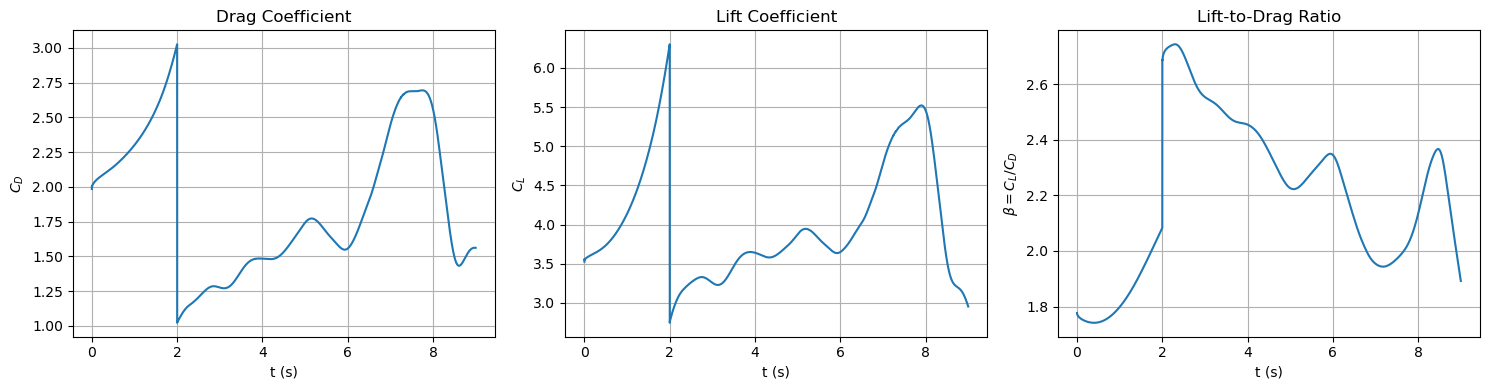

In [ ]:
cfd = CFDParameters(
    T=9, 
    dt=1600, 
    mu=0.00012, 
    rho=1.0, 
    mesh_filename=NACA_0012.msh_filename
    )

cfd.boundary_conditions(Re=2500, U_m=0.45)
cfd.IPCS(output_dir='initial_cfd_results', save_interval=20, t_ramp=2.0, name='uncontrolled')
cfd.save_checkpoint('checkpoints/naca0012_alpha25')
cfd.plot_results()

In [ ]:
# view your initial CFD results in paraview, you should see the expected vortex shedding pattern behind the airfoil.
# note: paraview may take a few seconds to open, and you need to click "apply" in the paraview interface to see the results. 
!paraview initial_cfd_results/pressure_uncontrolled.xdmf initial_cfd_results/velocity_uncontrolled.xdmf  

### RL Agent Training

The RL agent trains on **9 additional seconds** of controlled flow, picking up from the 9s uncontrolled checkpoint.

**Episode structure:**
- Each episode = 576 RL steps × 25 CFD steps × dt(1/1600 s) = **9 s of controlled flow**
- Observation: velocity `(u_x, u_y)` + pressure `p` (3, m, n) tensor obs. 
- Action: 3 jet flow rates, constrained to `> 3%` of the momentum intercepting the airfoil, exponentially smoothed (α=0.2)
- Reward: `r_t = ⟨b⟩_T − r_0` where `b = C_L/C_D` averaged over T=25 CFD steps, `r_0` is the uncontrolled baseline lift-to-drag ratio

**to do a run:** 1 episode (`total_timesteps=576`), need to train for 500-1000 episodes to learn optimal policy. A rising reward curve over full training means the agent is learning to sustain a higher lift-to-drag than the uncontrolled baseline.

**Inference:** After training, load the saved `.zip` policy, run one deterministic episode, and plot controlled vs uncontrolled `C_L/C_D` for validation. 

In [ ]:
import os
from src.env.AFCGYMenv import AFCGymEnv
from src.rl.RecPPOAgent import RecPPOAgent

CHECKPOINT = 'checkpoints/naca0012_alpha25'
SAVE_PATH  = 'results/training/learned_policy'
TB_LOG_DIR = os.path.abspath('results/tensorboard')

env = AFCGymEnv(
    airfoil_config  = NACA_0012,
    checkpoint_path = CHECKPOINT,
    mesh_filename   = NACA_0012.msh_filename,
    T_total         = 9.0,        # seconds of controlled flow per episode
    dt              = 1600,       # timesteps per second
    mu              = 0.00012,
    rho             = 1.0,
    Re              = 2500,
    U_m             = 0.45,
)

agent = RecPPOAgent(
    env             = env,
    use_cnn         = False,              # paper uses plain LSTM, no CNN
    learning_rate   = 5e-4,              # paper Table I
    n_steps         = env.episode_steps,  # one full episode per PPO update
    batch_size      = 64,                 # paper Table I
    n_epochs        = 10,
    gamma           = 0.99,               # paper Table I
    clip_range      = 0.2,                # paper Table I
    tensorboard_log = TB_LOG_DIR,
    verbose         = 1,
)

print(f"number of RL steps in one full episode : {env.episode_steps}")
print(f"TensorBoard   : {TB_LOG_DIR}")
# tensorboard --logdir results/tensorboard

Baseline lift-to-drag r_0 = 2.1689
Info    : Reading '/Users/biplovebaral/Desktop/AFC_DRL/simulation/configuration/geo_and_mesh/naca001234_25.msh'...
Info    : 56 entities
Info    : 278114 nodes
Info    : 140150 elements                                                                                     
Info    : Done reading '/Users/biplovebaral/Desktop/AFC_DRL/simulation/configuration/geo_and_mesh/naca001234_25.msh'
Mesh loaded — 70075 vertices, T=9.0s, steps=14400, dt=0.000625
BCs set — U_m=0.45, U_bar=0.3000, Re=2500, nu=0.000120
CFDEnvSolver initialized — matrices and solvers ready.
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
number of RL steps in one full episode : 576
TensorBoard   : /Users/biplovebaral/Desktop/AFC_DRL/simulation/RL_results/tensorboard


In [12]:
n_episodes = 1
agent.train(
    total_timesteps = env.episode_steps * n_episodes,
    save_path       = SAVE_PATH,
    tb_log_name     = "AFC_DRL_Test",   
    print_every     = 50,            # print how far long we are at the specified amount of steps, DRL feels like it takes decades so this eases your mind that stuff is actually being done. 
)

Logging to /Users/biplovebaral/Desktop/AFC_DRL/simulation/RL_results/tensorboard/AFC_DRL_Test_1
  step     50 / 576
  step    100 / 576
  step    150 / 576
  step    200 / 576
  step    250 / 576
  step    300 / 576
  step    350 / 576
  step    400 / 576
  step    450 / 576
  step    500 / 576
  step    550 / 576

>>> Episode 1 done | reward = -365.0444 | mean so far = -365.0444

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 576      |
|    ep_rew_mean     | -365     |
| time/              |          |
|    fps             | 0        |
|    iterations      | 1        |
|    time_elapsed    | 156338   |
|    total_timesteps | 576      |
---------------------------------
Policy saved: 'RL_results/training/learned_policy.zip'


see results on tensorboard: 

In [ ]:
!tensorboard --logdir results/tensorboard

/Users/biplovebaral/.local/share/mamba/envs/dolfinx_env/lib/python3.10/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
TensorFlow installation not found - running with reduced feature set.
Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C


In [ ]:
agent.load(SAVE_PATH, env=env)
C_D, C_L = agent.run_inference(env, save_dir='results/inference')